# Movie Poster Color Extraction

This notebook is image/data processing.

Goal: extract dominant color and brightness from movie posters and analyze trends by genre and year.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import subprocess
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

from io import BytesIO
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [ ]:
# load data
df = pd.read_csv("Final.Database.csv", skipinitialspace=True)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Genre"] = df["Genre"].fillna("Unknown")
print("Shape:", df.shape)
df.head(3)

Shape: (643, 4)


,Movie,Year,TMDB_Link,Genre
0,3 Idiots,2009.0,https://www.themoviedb.org/movie/20453,"Drama, Comedy"
1,Nanban,2012.0,https://www.themoviedb.org/movie/69537,"Comedy, Drama"
2,3 Idiotas,2017.0,https://www.themoviedb.org/movie/346034,"Family, Comedy"


In [ ]:
# TMDB API key
TMDB_API_KEY = os.getenv("TMDB_API_KEY", "18dea89aea654fde541b73b5f34e97da").strip()

In [14]:
def extract_movie_id(tmdb_link: str):
    try:
        path = str(tmdb_link).split("?")[0].rstrip("/").split("/")[-1]
        return path.split("-")[0]
    except Exception:
        return None

def get_poster_url(movie_id: str, api_key: str):
    if not movie_id or not api_key:
        return None
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={api_key}"
    r = requests.get(url, timeout=15)
    if r.status_code != 200:
        return None
    data = r.json()
    poster_path = data.get("poster_path")
    if not poster_path:
        return None
    return f"https://image.tmdb.org/t/p/w500{poster_path}"

def load_image_rgb(url: str):
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert("RGB")
    return img

def dominant_color_kmeans(img: Image.Image, n_clusters: int = 5):
    arr = np.array(img.resize((120, 180)))
    pixels = arr.reshape(-1, 3).astype(np.float32)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(pixels)
    counts = np.bincount(labels)
    dominant = km.cluster_centers_[counts.argmax()]
    return tuple(np.clip(dominant, 0, 255).astype(int))

def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(*rgb)

def brightness(rgb):
    # luminance approximation
    r, g, b = rgb
    return 0.299 * r + 0.587 * g + 0.114 * b

In [27]:
# i'm doing just a sample for now to see if it works
sample_n = 80
work = df.dropna(subset=["TMDB_Link"]).copy().head(sample_n)

records = []

if not TMDB_API_KEY:
    print("Cannot fetch posters without TMDB_API_KEY.")
else:
    for _, row in work.iterrows():
        movie_id = extract_movie_id(row["TMDB_Link"])
        poster_url = get_poster_url(movie_id, TMDB_API_KEY)
        if not poster_url:
            continue

        try:
            img = load_image_rgb(poster_url)
            dom = dominant_color_kmeans(img, n_clusters=5)
            records.append({
                "Movie": row["Movie"],
                "Year": row["Year"],
                "Genre": row["Genre"],
                "PosterURL": poster_url,
                "R": dom[0],
                "G": dom[1],
                "B": dom[2],
                "HEX": rgb_to_hex(dom),
                "Brightness": brightness(dom)
            })
        except Exception:
            continue

color_df = pd.DataFrame(records)
print("Extracted posters:", len(color_df))
color_df.head()

Extracted posters: 78


,Movie,Year,Genre,PosterURL,R,G,B,HEX,Brightness
0,3 Idiots,2009.0,"Drama, Comedy",https://image.tmdb.org/t/p/w500/66A9MqXOyVFCss...,235,212,82,#ebd452,204.057
1,Nanban,2012.0,"Comedy, Drama",https://image.tmdb.org/t/p/w500/dmhPnvYQVtx4xS...,223,95,58,#df5f3a,129.054
2,3 Idiotas,2017.0,"Family, Comedy",https://image.tmdb.org/t/p/w500/hZB9NvNLcxdmoi...,116,99,83,#746353,102.259
3,Pyar Jhukta Nahin,1985.0,Unknown,https://image.tmdb.org/t/p/w500/oV7tPeC8f5KEPJ...,51,36,54,#332436,42.537
4,Nee Bareda Kadambari,1985.0,"Drama, Romance",https://image.tmdb.org/t/p/w500/fqWOLyiLy8R77j...,237,228,232,#ede4e8,231.147


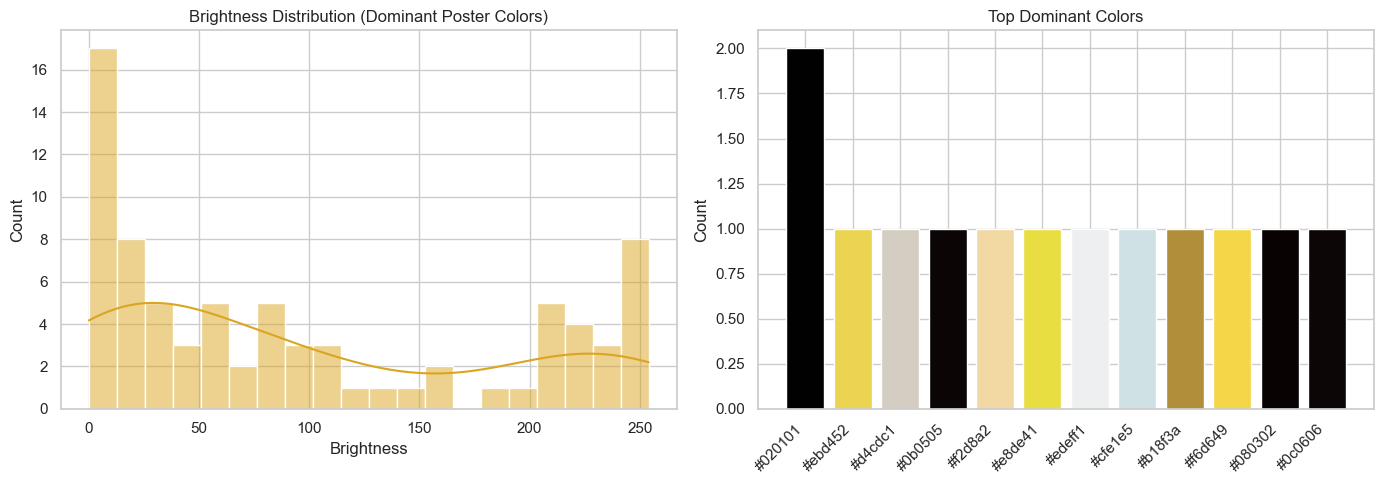

In [28]:
if len(color_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(color_df["Brightness"], bins=20, kde=True, ax=axes[0], color="goldenrod")
    axes[0].set_title("Brightness Distribution (Dominant Poster Colors)")

    top_hex = color_df["HEX"].value_counts().head(12)
    bars = axes[1].bar(range(len(top_hex)), top_hex.values, color=top_hex.index)
    axes[1].set_title("Top Dominant Colors")
    axes[1].set_xticks(range(len(top_hex)))
    axes[1].set_xticklabels(top_hex.index, rotation=45, ha="right")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

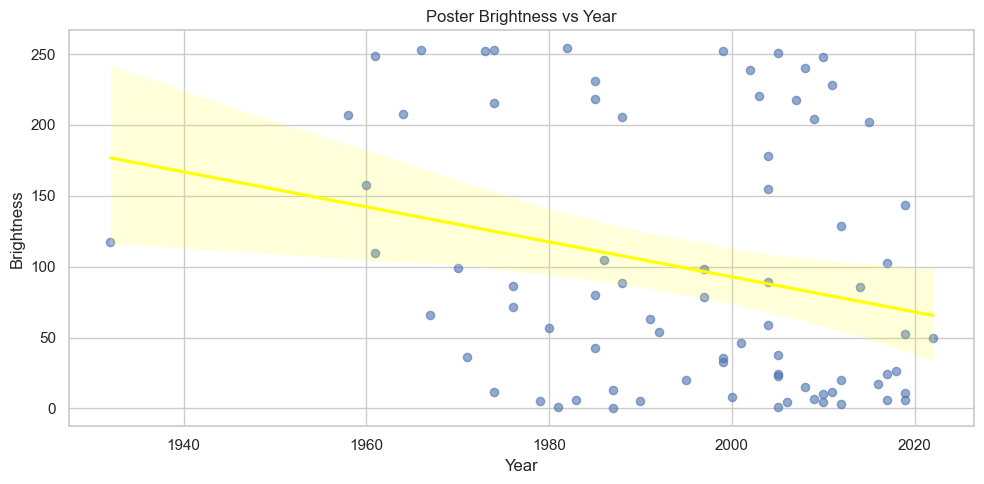

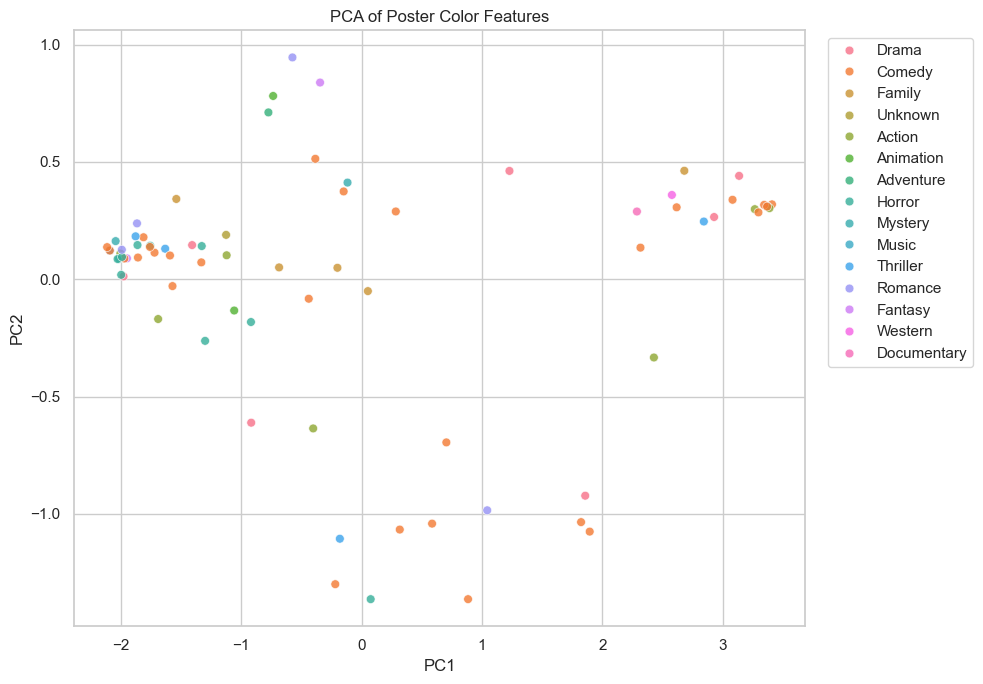

In [29]:
if len(color_df) > 5:
    plot_df = color_df.dropna(subset=["Year"]).copy()
    plt.figure(figsize=(10, 5))
    sns.regplot(data=plot_df, x="Year", y="Brightness", scatter_kws={"alpha":0.6, "s":35}, line_kws={"color":"yellow"})
    plt.title("Poster Brightness vs Year")
    plt.tight_layout()
    plt.show()

    X_color = plot_df[["R", "G", "B", "Brightness"]].values
    X_color = StandardScaler().fit_transform(X_color)
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_color)

    pca_df = pd.DataFrame({
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "Genre": plot_df["Genre"].astype(str).str.split(",").str[0].str.strip()
    })

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Genre", s=40, alpha=0.8)
    plt.title("PCA of Poster Color Features")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [12]:
if len(color_df) > 0:
    out_path = "poster_color_features.csv"
    color_df.to_csv(out_path, index=False)
    print("Saved:", out_path)
    color_df.describe(include="all").T

Saved: poster_color_features.csv


## Interpretation checklist
- Compare dominant colors across genres.
- Evaluate brightness trend through years.
- Use `poster_color_features.csv` as extra features for clustering/classification models in your milestone notebook.